In [1]:
import numpy as np
import matplotlib.pyplot as plt

Primeiramente, instanciamos o gerador de números aleatórios e usamos para gerar uma matriz grid $NxN$ com valores $-1$ ou $1$. Geramos também dois arrays com índices aleátorios da grid.

In [2]:
rng = np.random.default_rng()
N = 50 # Matriz 50x50
grid = rng.choice([1,-1], size=(N,N))
sweeps = 500
passos = sweeps * (N*N)
i_arr = rng.integers(0,N, size = passos)
j_arr = rng.integers(0,N, size = passos)


Para aplicar o modelo Ising, precisamos entender o Hamiltoniano:
$$E = -J \sum_{\langle i,j \rangle} s_i s_j$$
Onde $s_i$ e $s_j$ são os valores dos spins ($-1$ ou $1$). $\langle i,j \rangle$ significa que fazemos o somatório de cada spin com seus vizinhos (cima, baixo, esquerda, direita).  $J$ é a constante de acoplamento.

In [3]:

def IsingModel(J,T):
    m = []
    for k in range(passos):
        i = i_arr[k]
        j = j_arr[k]
        spin = grid[i,j]
        vizinhos = (grid[(i + 1) % N, j] + 
                    grid[(i - 1) % N, j] + 
                    grid[i, (j + 1) % N] + 
                    grid[i, (j - 1) % N])
        dE = 2 * J * spin * vizinhos
        
        if dE <= 0:
            grid[i, j] *= -1  #
        else:
            probabilidade = np.exp(-dE / T)
            if rng.random() < probabilidade:
                grid[i, j] *= -1 
        if k % 1000 == 0:
            m.append(np.abs(np.mean(grid)))

    return grid, dE, m

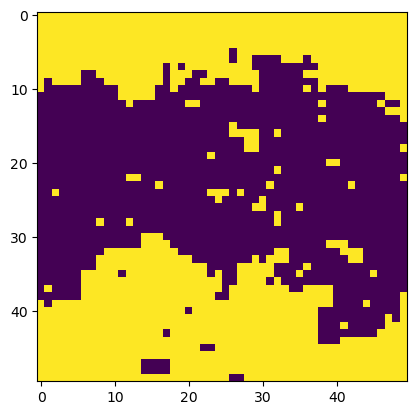

In [4]:
J = 1.0 # Constante de Acoplamento
T = 2 # Temperatura

grid,dE,m = IsingModel(J,T)
plt.imshow(grid)







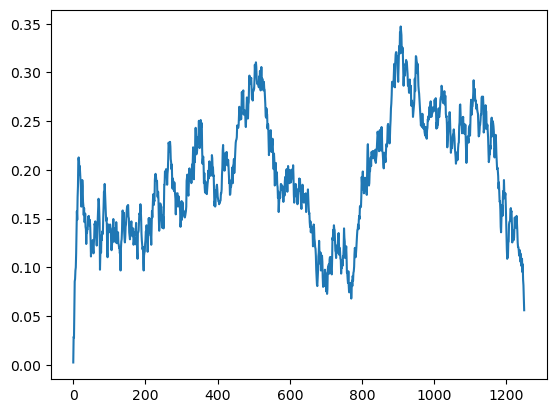

In [7]:
plt.plot(m)